In [52]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

# 1D Linear inverse problem

$$g_j = e^{jpx} cos (2\pi j qx) $$

In [53]:
def get_G_matrix(M, N, p, q, j0=1, jN=30):
    """
    Comments
    """
    x_node = np.linspace(0, 1, M+1)
    x_center = (x_node[1:] + x_node[:-1]) * 0.5
    G_node = np.zeros((M+1, N))
    j_values = np.linspace(j0, jN, N)
    for jj, j in enumerate(j_values):
        G_node[:,jj] = np.exp(j*p*x_node) * np.cos(2*np.pi*q*j*x_node)
    dx = np.diff(x_node)    
    Av = sp.spdiags(np.ones((2, M+1))*0.5, [0, 1], M, M+1)
    dx_diag = sp.spdiags(dx, [0], M, M)
    G = G_node.T @ Av.T @  dx_diag     
    return G, x_center

In [54]:
def get_model(
    x_centers, 
    x_boxcar_min=0.6, x_boxcar_max=0.8, amplitude_boxcar=0.5, 
    x0_gaussian=0.3, sigma_gaussian=0.07, amplitude_gaussian=0.35
):
    
    # initialize empty model
    model = np.zeros_like(x_centers)

    # create boxcar
    inds_boxcar = (x_centers > x_boxcar_min) & (x_centers < x_boxcar_max)
    model[inds_boxcar] = amplitude_boxcar

    # define_gaussian
    def gaussian(x, x0, sigma): 
        return np.exp(-(x - x0)**2 / (2*sigma**2))

    return model + amplitude_gaussian * gaussian(x_centers, x0_gaussian, sigma_gaussian)

## Linear problem

$$\mathbf{G}\mathbf{m}=\mathbf{d}$$

In [99]:
M = 100
N = 30
p = -0.05
q = 0.1
G, x_center = get_G_matrix(M, N, p, q, j0=1, jN=30)
m = get_model(x_center)
dpred = G @ m 

In [100]:
G.shape

(30, 100)

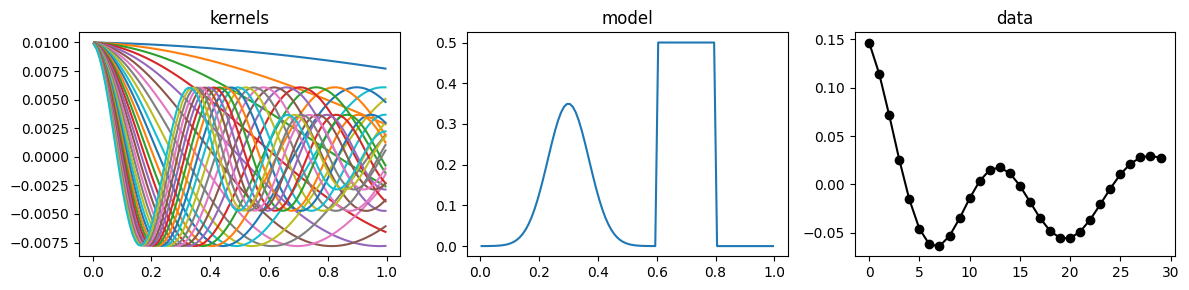

In [101]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].plot(x_center, G.T)
ax[1].plot(x_center, m)
ax[2].plot(dpred, "-o", color="k")

ax[0].set_title("kernels")
ax[1].set_title("model")
ax[2].set_title("data")

plt.tight_layout();

In [102]:
dpred = G @ m
dobs = dpred.copy()

In [96]:
# Add the least square solution: 


In [107]:
# plt.plot(x_center, m_est)
# plt.plot(x_center, m)

## Let's add a regularization term

 $$\phi(m) = \phi_d(m) + \beta \phi_m(m)$$

$$ \phi_m = \alpha_s \int (m)^2 $$

In [105]:
# Ws = sp.spdiags(np.ones(M), [0], M, M)
# beta = 0.001
# m_est = np.linalg.solve(G.T @ G + beta*Ws.T@Ws, G.T @ dpred)